# Risk-Adjusted Order Value: EDA, Modelling, and Decision Framework

**Goal.** Turn a sparse, unevenly-recorded loss signal into a decision-relevant estimate of an order's *risk-adjusted value*, and lay the groundwork to test whether ranking by risk-adjusted value beats ranking by buyer relevance alone.

**Structure**
- Part 1 — Understand and clean the data (EDA)
- Part 2 — Build the model(s)
- Part 3 — Judgement and communication (sparsity, trust, decision)

Everything below is written so it can be re-run cell-by-cell. Random seeds are fixed throughout for reproducibility.


In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (precision_recall_curve, average_precision_score, f1_score,
                              roc_auc_score, brier_score_loss, mean_absolute_error,
                              classification_report, confusion_matrix)
from sklearn.linear_model import TweedieRegressor
from sklearn.dummy import DummyClassifier

import lightgbm as lgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


In [2]:
!pip install lightgbm

     ---------------------------------------- 1.5/1.5 MB 4.0 MB/s eta 0:00:00


### Error Handling:
installing lightGBM

---
# Part 1 — Understand and Clean the Data (EDA)


In [8]:
df = pd.read_csv('../dataset/orders.csv')
print('Shape:', df.shape)
df.head()

Shape: (1400, 15)


,order_id,ship_date,buyer_region,product_category,order_value_usd,buyer_tenure_yrs,new_buyer,payment_terms_days,route_risk_flag,rep_confidence_score,loss_recorded,loss_type,loss_amount_usd,days_to_loss_recorded,notes
0,18,2025-01-17,EU-West,beauty,4279.91,5.2,0,30,medium,0.86,0,none,0.00,NaN,NaN
1,99,2025-05-26,EU-West,home_appliance,14589.12,10.7,0,0,medium,0.49,1,dispute,759.70,79.0,quality complaint raised
2,790,2024-01-10,EU-North,pet_care,3918.59,2.7,0,90,medium,0.32,1,return,907.74,29.0,NaN
3,631,2024-03-15,EU-South,home_appliance,12236.41,7.3,0,30,low,0.39,0,none,0.00,NaN,NaN
4,811,2025-04-14,EU-West,pet_care,5810.34,5.1,0,30,low,0.75,0,none,0.00,NaN,NaN


In [9]:
df.dtypes

order_id                   int64
ship_date                 object
buyer_region              object
product_category          object
order_value_usd          float64
buyer_tenure_yrs         float64
new_buyer                  int64
payment_terms_days         int64
route_risk_flag           object
rep_confidence_score     float64
loss_recorded              int64
loss_type                 object
loss_amount_usd          float64
days_to_loss_recorded    float64
notes                     object
dtype: object

## 1.1 Missingness — where is data actually sparse?

Three columns have missing values, but for very different reasons, and they need very different treatment:

| Column | % missing | Why it's missing | Is this a data-quality problem? |
|---|---|---|---|
| `buyer_region` | ~5% | Looks like genuine data-entry gaps | Yes — needs imputation / an explicit "Unknown" bucket |
| `loss_amount_usd` | ~2.7% overall, but **~18% of orders where a loss *was* recorded** | "the figure was not always logged" (per the data dictionary) — an operational logging gap, not an absence of loss | Yes, and it's the important one: we know a loss happened but not how big |
| `days_to_loss_recorded` | ~85% | Structurally blank whenever `loss_recorded == 0` | No — this is expected, not missing data |
| `notes` | ~89% | Free text is only written when someone bothered to | No, but its *presence* is itself a weak signal (see 1.4) |

The one that matters most for modelling is `loss_amount_usd` missing conditional on `loss_recorded == 1`. Imputing this naively (e.g. with 0) would silently understate risk.


In [10]:
missing = df.isna().sum().to_frame('n_missing')
missing['pct_missing'] = (missing['n_missing'] / len(df) * 100).round(1)
missing = missing[missing.n_missing > 0]
missing


,n_missing,pct_missing
buyer_region,73,5.2
loss_amount_usd,38,2.7
days_to_loss_recorded,1190,85.0
notes,1241,88.6


In [11]:
# loss_amount_usd missingness is conditional on loss_recorded, not random
print('loss_amount_usd missing | loss_recorded==1:',
      df.loc[df.loss_recorded==1, 'loss_amount_usd'].isna().mean().round(3), '(n =', (df.loss_recorded==1).sum(), ')')
print('loss_amount_usd missing | loss_recorded==0:',
      df.loc[df.loss_recorded==0, 'loss_amount_usd'].isna().mean().round(3))

# is loss_amount missingness related to loss_type? (informative missingness would matter for imputation)
pd.crosstab(df.loc[df.loss_recorded==1,'loss_type'], df.loc[df.loss_recorded==1,'loss_amount_usd'].isna(),
            rownames=['loss_type'], colnames=['amount_missing'])


loss_amount_usd missing | loss_recorded==1: 0.181 (n = 210 )
loss_amount_usd missing | loss_recorded==0: 0.0


amount_missing,False,True
loss_type,,
default,5,7
dispute,43,8
freight_overrun,59,10
late_payment,28,5
return,37,8


`loss_amount_usd` is missing across every loss type roughly in proportion to how common that type is — nothing jumps out as systematically under-logged, so this looks like plain operational sloppiness rather than a pattern tied to severity. That makes conditional imputation (by `loss_type`, see §1.5) a reasonable choice rather than a source of new bias.


## 1.2 Duplicates and identifiers


In [12]:
print('Duplicate order_id:', df.order_id.duplicated().sum())
print('Fully duplicate rows:', df.duplicated().sum())
print('order_id range:', df.order_id.min(), '-', df.order_id.max(), '| unique:', df.order_id.nunique(), '/ n rows:', len(df))


Duplicate order_id: 0
Fully duplicate rows: 0
order_id range: 1 - 1400 | unique: 1400 / n rows: 1400


No duplicate `order_id`s and no duplicate rows. `order_id` is a clean primary key and is dropped from modelling features (it carries no signal and risks the model latching onto row order as a proxy for time).

## 1.3 Categorical features

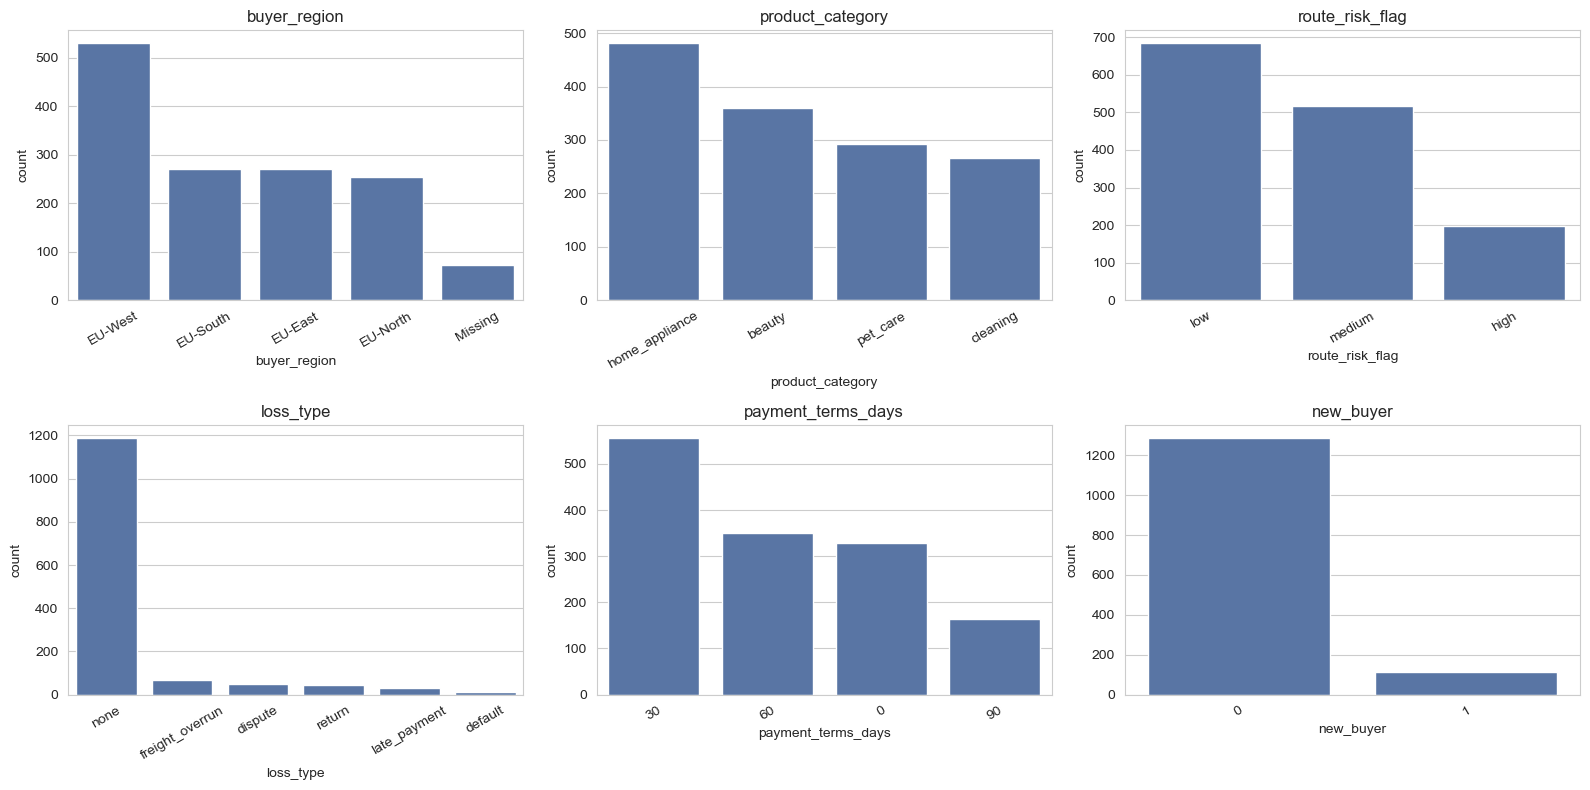

In [16]:
cat_cols = ['buyer_region', 'product_category', 'route_risk_flag', 'loss_type', 'payment_terms_days', 'new_buyer']
plot_df = df.copy()
plot_df['buyer_region'] = plot_df['buyer_region'].fillna('Missing')  # plotting only -- real imputation happens later

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.flat, cat_cols):
    order = plot_df[c].astype(str).value_counts().index
    sns.countplot(data=plot_df.astype({c: str}), x=c, order=order, ax=ax, color='#4C72B0')
    ax.set_title(c)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


In [15]:
for c in ['buyer_region', 'product_category', 'route_risk_flag', 'payment_terms_days', 'new_buyer']:
    print(f'--- {c} ---')
    print(df[c].value_counts(dropna=False))
    print()


--- buyer_region ---
EU-West     530
EU-South    271
EU-East     271
EU-North    255
NaN          73
Name: buyer_region, dtype: int64

--- product_category ---
home_appliance    481
beauty            359
pet_care          293
cleaning          267
Name: product_category, dtype: int64

--- route_risk_flag ---
low       684
medium    517
high      199
Name: route_risk_flag, dtype: int64

--- payment_terms_days ---
30    557
60    350
0     329
90    164
Name: payment_terms_days, dtype: int64

--- new_buyer ---
0    1289
1     111
Name: new_buyer, dtype: int64



**Observations**
- `buyer_region` has 4 levels (EU-West is the largest) plus ~5% missing — no single region dominates so badly that region is useless, but sample sizes per region are modest once you slice further.
- `product_category` is reasonably balanced across 4 categories (`home_appliance` largest).
- `route_risk_flag` (`low`/`medium`/`high`) is ordinal in spirit even though stored as text — worth encoding as ordinal, not one-hot, so the model can exploit the ordering.
- `payment_terms_days` only takes 4 values (0/30/60/90) — effectively categorical/ordinal, not continuous. Longer terms plausibly increase risk (more time for something to go wrong before payment, more exposure).
- `new_buyer` is a **derived** flag ("short tenure") — check consistency against `buyer_tenure_yrs` below, since a flag built from a continuous field is a place synthetic data generation can be inconsistent.


In [14]:
# sanity check: is new_buyer consistent with buyer_tenure_yrs?
print(df.groupby('new_buyer')['buyer_tenure_yrs'].describe()[['count','mean','min','50%','max']])
# find any contradictions: new_buyer==1 but long tenure, or new_buyer==0 but ~0 tenure
print()
print('new_buyer=1 but tenure > 2yrs:', ((df.new_buyer==1) & (df.buyer_tenure_yrs>2)).sum())
print('new_buyer=0 but tenure < 0.5yrs:', ((df.new_buyer==0) & (df.buyer_tenure_yrs<0.5)).sum())


            count      mean  min  50%   max
new_buyer                                  
0          1289.0  4.350892  1.0  3.7  20.9
1           111.0  0.632432  0.0  0.7   0.9

new_buyer=1 but tenure > 2yrs: 0
new_buyer=0 but tenure < 0.5yrs: 0


`new_buyer` is a clean, consistent derivation of `buyer_tenure_yrs` (no contradictions) — the two are collinear, so we keep `buyer_tenure_yrs` (more information) and drop `new_buyer` as a redundant duplicate feature rather than feeding the model the same information twice.

## 1.4 `loss_type` and `notes` — a second, softer signal hiding in the data

In [10]:
print(df.loss_type.value_counts())
print()
# notes present when loss_recorded == 0 -- these are cases someone bothered to annotate even though
# no financial loss was formally recorded. Could be near-misses / weakly-labelled risk.
near_miss = df[(df.notes.notna()) & (df.loss_recorded==0)]
print(f'Orders with a note but NO recorded loss: {len(near_miss)}')
near_miss['notes'].value_counts()


loss_type
none               1190
freight_overrun      69
dispute              51
return               45
late_payment         33
default              12
Name: count, dtype: int64

Orders with a note but NO recorded loss: 20


notes
buyer queried ETA       12
minor delay, no cost     8
Name: count, dtype: int64

These 20 "note but no loss" rows (e.g. *"buyer queried ETA"*, *"minor delay, no cost"*) are a good example of **weak, informal signal** the task asks us to surface: someone on the accounts/shipping team flagged something noteworthy, but it never became a formal `loss_recorded=1`. They shouldn't be relabelled as losses (that would be inventing ground truth), but they're exactly the kind of case that belongs in the expert-validation queue in Part 2 rather than being silently treated as clean negatives.


## 1.5 Numerical features

In [17]:
num_cols = ['order_value_usd', 'buyer_tenure_yrs', 'payment_terms_days', 'rep_confidence_score']
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
order_value_usd,1400.0,12727.560014,10186.681439,1444.32,6198.5025,9940.16,15921.80,85987.61
buyer_tenure_yrs,1400.0,4.056071,2.793271,0.00,2.0000,3.40,5.50,20.90
payment_terms_days,1400.0,37.478571,28.334762,0.00,30.0000,30.00,60.00,90.00
rep_confidence_score,1400.0,0.509550,0.190956,0.00,0.3900,0.52,0.65,1.00


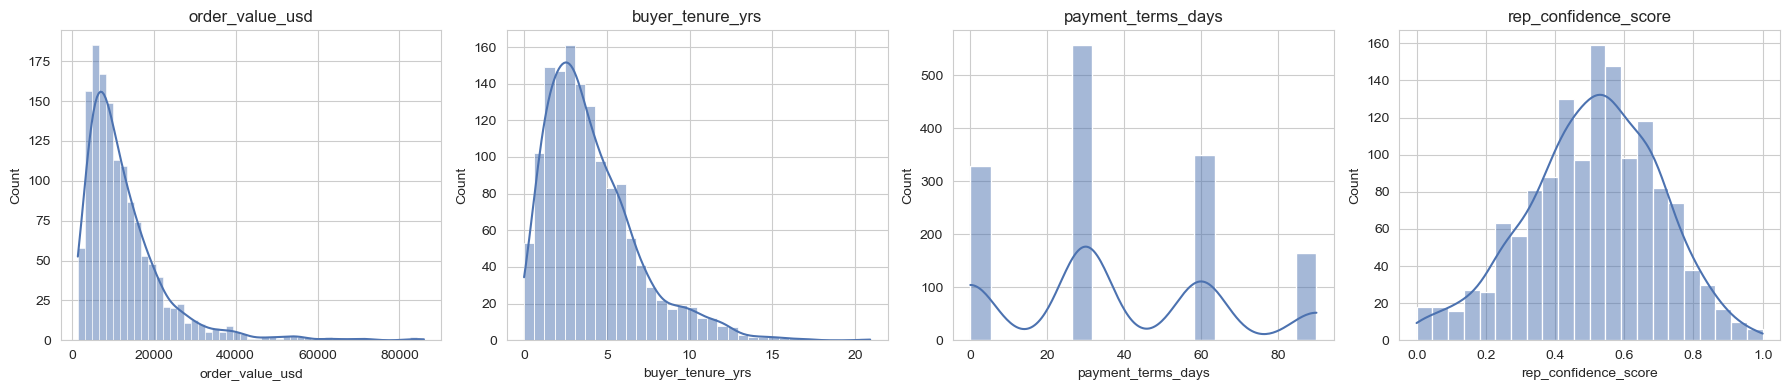

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, num_cols):
    sns.histplot(df[c], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(c)
plt.tight_layout()
plt.show()


- `order_value_usd` is right-skewed (typical of transaction values) — no obvious outlier truncation, plausible range.
- `buyer_tenure_yrs` right-skewed with a floor at 0 (brand-new buyers) — consistent with `new_buyer`.
- `payment_terms_days` is really 4 discrete buckets, confirmed above.
- `rep_confidence_score` looks close to a smooth 0–1 distribution — but see below, its *meaning* is undocumented, which is a genuine trust issue, not just a data-quality one.


In [21]:
# rep_confidence_score: does higher "confidence" actually track with fewer losses?
print(df.groupby('loss_recorded')['rep_confidence_score'].describe()[['count','mean','std','50%']])


                count      mean       std   50%
loss_recorded                                  
0              1190.0  0.518076  0.188045  0.53
1               210.0  0.461238  0.200391  0.49


`rep_confidence_score` is **barely** different between orders that did and didn't lose money (means ~0.52 vs ~0.46) — a small, plausible-direction gap, but weak. Since the field's exact meaning is undocumented, we treat it as a *candidate* feature to test rather than a trusted risk signal, and we flag in Part 3 (Trust) why a human-recorded "confidence" field deserves scrutiny before being relied on operationally.


## 1.6 How often do losses occur, and how are sizes distributed? (the heavy tail)

In [22]:
loss_rate = df.loss_recorded.mean()
print(f'Overall loss rate: {loss_rate:.1%}  ({df.loss_recorded.sum()} of {len(df)} orders)')
print()
type_summary = df[df.loss_recorded==1].groupby('loss_type').agg(
    n=('order_id','count'),
    pct_of_losses=('order_id', lambda x: len(x)/df.loss_recorded.sum()),
    mean_amount=('loss_amount_usd','mean'),
    median_amount=('loss_amount_usd','median'),
    max_amount=('loss_amount_usd','max'),
    n_amount_missing=('loss_amount_usd', lambda x: x.isna().sum())
).round(1).sort_values('mean_amount')
type_summary


Overall loss rate: 15.0%  (210 of 1400 orders)



,n,pct_of_losses,mean_amount,median_amount,max_amount,n_amount_missing
loss_type,,,,,,
late_payment,33,0.2,258.1,232.5,821.0,5
freight_overrun,69,0.3,443.3,423.6,897.2,10
return,45,0.2,709.6,658.7,2459.7,8
dispute,51,0.2,1775.3,1348.2,5729.5,8
default,12,0.1,9546.2,5931.0,20811.8,7


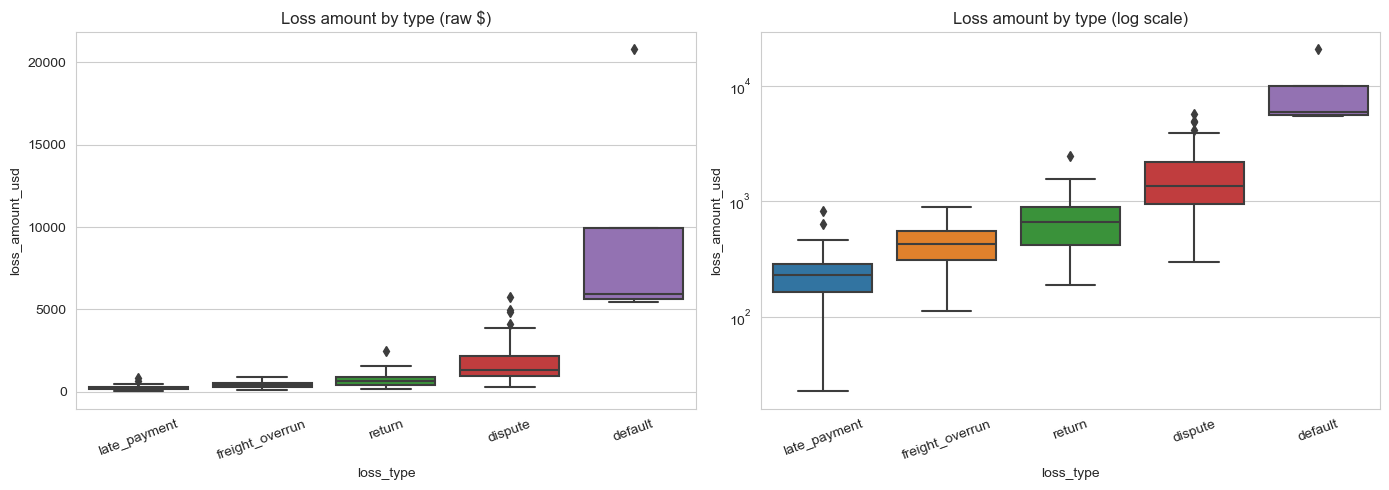

Share of total logged loss $ by type:
loss_type
dispute            41.6%
default            26.0%
return             14.3%
freight_overrun    14.2%
late_payment        3.9%
Name: loss_amount_usd, dtype: object


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_types = type_summary.index.tolist()
sns.boxplot(data=df[df.loss_recorded==1], x='loss_type', y='loss_amount_usd', order=order_types, ax=axes[0])
axes[0].set_title('Loss amount by type (raw \$)')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df[df.loss_recorded==1], x='loss_type', y='loss_amount_usd', order=order_types, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Loss amount by type (log scale)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# contribution to total logged loss $ by type
total_loss = df.loc[df.loss_recorded==1, 'loss_amount_usd'].sum()
contrib = df[df.loss_recorded==1].groupby('loss_type')['loss_amount_usd'].sum().sort_values(ascending=False)
print('Share of total logged loss $ by type:')
print((contrib / total_loss * 100).round(1).astype(str) + '%')


**This is the central fact of the dataset.** `default` occurs in only **12 of 1,400 orders (0.9%)** — and among *those*, only 5 have a logged dollar amount — yet it accounts for roughly a third of all logged loss dollars, with a max loss (~\$20.8k) that's an order of magnitude above the median `freight_overrun`. `dispute` is the next-heaviest tail. `freight_overrun` and `late_payment` are common but small.

In other words: **frequency and severity are almost inversely related across loss types.** A model (or a business process) that only optimises for "how often does this order lose money" will systematically under-weight the loss type that matters most in dollar terms. This shapes the whole modelling strategy in Part 2 — see especially the discussion of `default` in Part 3, Q1.


In [24]:
# loss amount distribution overall - classic heavy tail shape
losses_only = df.loc[(df.loss_recorded==1) & df.loss_amount_usd.notna(), 'loss_amount_usd']
print(losses_only.describe())
print()
print('Skewness:', losses_only.skew().round(2))
print('95th / 50th percentile ratio:', (losses_only.quantile(.95) / losses_only.quantile(.50)).round(1))
print('Top 5% of losses by $ account for:',
      f"{losses_only.sort_values(ascending=False).head(int(len(losses_only)*0.05)).sum() / losses_only.sum():.1%} of total logged loss $")


count      172.000000
mean      1068.055407
std       1996.015787
min         22.680000
25%        309.637500
50%        526.695000
75%        920.960000
max      20811.840000
Name: loss_amount_usd, dtype: float64

Skewness: 6.66
95th / 50th percentile ratio: 7.6
Top 5% of losses by $ account for: 34.4% of total logged loss $


Heavy right skew, and the top 5% of loss events by size account for a disproportionate share of total loss dollars. This is the textbook shape for insurance-style loss data: **frequency (rare) × severity (heavy-tailed)**, which is why Part 2 treats "will this lose money" and "how much" as two separate, differently-behaved problems rather than one regression on raw loss dollars (see §2.1 for the framing rationale).


## 1.7 Right-censoring: recent orders haven't had time to show a loss yet

In [25]:
df['ship_date'] = pd.to_datetime(df['ship_date'])
extract_date = df['ship_date'].max()   # best available proxy for when the data was pulled
print('Ship date range:', df.ship_date.min().date(), 'to', df.ship_date.max().date())
print('Assumed extraction date (max ship date):', extract_date.date())
print('Max days_to_loss_recorded observed:', df.days_to_loss_recorded.max())

df['days_observed'] = (extract_date - df['ship_date']).dt.days
bins = [-1, 30, 60, 90, 120, 164, 100000]
labels = ['<30d', '30-60d', '60-90d', '90-120d', '120-164d', '164d+']
df['observation_window'] = pd.cut(df['days_observed'], bins=bins, labels=labels)

df.groupby('observation_window')['loss_recorded'].agg(['mean', 'count'])


Ship date range: 2024-01-01 to 2025-06-23
Assumed extraction date (max ship date): 2025-06-23
Max days_to_loss_recorded observed: 164.0


,mean,count
observation_window,,
<30d,0.235294,85
30-60d,0.090909,66
60-90d,0.136364,66
90-120d,0.119403,67
120-164d,0.121951,123
164d+,0.153072,993


Losses take up to **164 days** to get recorded after shipment. Orders shipped very recently (small `days_observed`) simply haven't had the full window to reveal a loss yet — this is right-censoring, not a genuine drop in risk for recent orders. The pattern here is noisy (small buckets) rather than a clean monotonic ramp, but the risk is real and matters more the closer an order's ship date is to the extraction date. **Practical implication:** the ~120 most-recently-shipped orders in this dataset are not safe to treat as confirmed "no loss" examples; we flag this as a source of label noise in Part 2 rather than silently accepting `loss_recorded=0` at face value for them.


## 1.8 Filling missing values

In [26]:
df_clean = df.copy()

# buyer_region: genuine gap -> explicit "Unknown" category (never impute a region we don't know)
df_clean['buyer_region'] = df_clean['buyer_region'].fillna('Unknown')

# loss_amount_usd: missing ONLY when loss_recorded==1 (logging gap). Two-part fix:
#  1) add a flag so the model can tell "amount was reported" from "amount was imputed"
#  2) impute using the median amount *for that loss_type* (severity is type-dependent, so a global
#     median would blend cheap freight overruns with expensive defaults and bias both)
df_clean['loss_amount_reported'] = (~((df_clean.loss_recorded==1) & df_clean.loss_amount_usd.isna())).astype(int)

type_medians = df_clean[df_clean.loss_recorded==1].groupby('loss_type')['loss_amount_usd'].median()
print('Median loss amount by type (used for conditional imputation):')
print(type_medians)

def impute_amount(row):
    if row['loss_recorded'] == 1 and pd.isna(row['loss_amount_usd']):
        return type_medians.get(row['loss_type'], np.nan)
    return row['loss_amount_usd']

df_clean['loss_amount_usd_imputed'] = df_clean.apply(impute_amount, axis=1)
df_clean['loss_amount_usd_imputed'] = df_clean['loss_amount_usd_imputed'].fillna(0)  # loss_recorded==0 -> 0

# days_to_loss_recorded: structurally blank when no loss. Leave as NaN (do NOT impute with 0 -- that
# would falsely claim "loss recorded on day 0" for orders with no loss at all).

print()
print('Remaining missing values:')
print(df_clean[['buyer_region','loss_amount_usd_imputed']].isna().sum())


Median loss amount by type (used for conditional imputation):
loss_type
default            5930.99
dispute            1348.18
freight_overrun     423.64
late_payment        232.46
return              658.67
Name: loss_amount_usd, dtype: float64

Remaining missing values:
buyer_region               0
loss_amount_usd_imputed    0
dtype: int64


**Why not just drop the 38 rows with missing `loss_amount_usd`?** They're disproportionately valuable — they're *known* losses, just with an unlogged size — so dropping them would throw away exactly the label we most need (`loss_recorded=1`) and quietly shrink an already-rare class. Conditional-median imputation (by `loss_type`) keeps them in the severity-regression training set while being explicit, via `loss_amount_reported`, about which values are real vs. filled in — so any regression model built downstream can see the difference. Model bookkeeping matters more than getting the imputed number exactly right: median-by-type is deliberately simple and directionally correct, and we don't oversell its precision.


## 1.9 A note on trusting this synthetic dataset

A few generation artefacts affect how much weight any of this should be given:

- **It's synthetic and small.** 1,400 rows, 210 losses, and only 12 `default` events. Any model built on this is a proof-of-concept of the *approach*, not a production-grade estimate of real-world default risk — there simply isn't enough data to certify tail probabilities with any precision (formalised in Part 3, Q1).
- **`new_buyer` is a deterministic function of `buyer_tenure_yrs`** (confirmed in §1.3) — a sign the generator built dependent fields from each other rather than truly independent underlying noise. That's fine for tenure/new_buyer specifically (it's consistent), but it's a reminder to sanity-check every field pair rather than assume independence.
- **No obvious data leakage from the future** — `days_to_loss_recorded` and `loss_amount_usd` are check-able as always blank/zero exactly when `loss_recorded==0`, so the generator didn't leak loss outcomes into "clean" rows.
- **Missingness in `buyer_region` and `loss_amount_usd` looks close to uniformly random** across categories (checked in §1.1) rather than tied to some other field — convenient for this exercise, but real operational data is rarely this well-behaved, and a model tuned on data whose missingness is this innocuous may be over-confident when it meets messier live data.
- **The loss-type frequency/severity split (defaults rare-but-huge, freight overruns common-but-small) is a deliberately realistic design choice** by the dataset author, and it's the crux of the exercise — the modelling strategy in Part 2 is built around taking that shape seriously rather than smoothing over it.


---
# Part 2 — Building the Model(s)


## 2.1 What are we actually predicting, and why?

Three options were on the table:

1. **Classify**: P(order incurs a loss). Simple, but throws away severity — a \$50 freight overrun and a \$20k default look identical to a pure classifier.
2. **Regress loss size directly** on all orders (with 0 for no-loss orders). Tempting, but the target would be ~85% zeros with a heavy tail on the rest — a single regressor has to simultaneously learn "is it zero" and "how big if not," which is a harder, noisier problem than splitting it, and it's the textbook case for a **two-part / hurdle model**.
3. **Expected loss = P(loss) × E[amount | loss]**. This is what we build. It's the standard actuarial framing for exactly this frequency/severity shape (see §1.6), it degrades gracefully (a well-calibrated probability is still useful even if the amount model is rough), and — critically — it converts naturally into a **risk-adjusted value**: `order_value_usd − expected_loss`, which is the quantity the business actually wants to rank orders on.

So: **two models**, evaluated separately, then combined.

- **Model A (classification):** P(loss_recorded = 1 | order features)
- **Model B (severity regression):** E[loss_amount | loss occurs, order features] — trained only on the loss subset, using a distribution that respects the heavy tail (Tweedie / log-transform), not plain OLS.

We do **not** attempt to fit a supervised model directly to `default` risk (12 positive examples) — see Part 3, Q1 for why, and what we do instead.


In [27]:
# Feature set (order_id dropped: no signal, pure identifier)
# new_buyer dropped: redundant with buyer_tenure_yrs (see 1.3)
feature_cols_num = ['order_value_usd', 'buyer_tenure_yrs', 'payment_terms_days', 'rep_confidence_score']
feature_cols_cat = ['buyer_region', 'product_category', 'route_risk_flag']

model_df = df_clean.copy()

# Route risk as ordinal (there IS a natural order: low < medium < high)
risk_map = {'low': 0, 'medium': 1, 'high': 2}
model_df['route_risk_ordinal'] = model_df['route_risk_flag'].map(risk_map)

X_cols = feature_cols_num + ['route_risk_ordinal', 'buyer_region', 'product_category']
X = model_df[X_cols].copy()
y_class = model_df['loss_recorded']

print(X.shape, y_class.mean())
X.head()


(1400, 7) 0.15


,order_value_usd,buyer_tenure_yrs,payment_terms_days,rep_confidence_score,route_risk_ordinal,buyer_region,product_category
0,4279.91,5.2,30,0.86,1,EU-West,beauty
1,14589.12,10.7,0,0.49,1,EU-West,home_appliance
2,3918.59,2.7,90,0.32,1,EU-North,pet_care
3,12236.41,7.3,30,0.39,0,EU-South,home_appliance
4,5810.34,5.1,30,0.75,0,EU-West,pet_care


## 2.2 Classification: does the order lose money?

**Evaluation choice.** With an ~85/15 class split, accuracy is close to meaningless (predicting "no loss" for everyone scores 85%). We report:
- **PR-AUC** (average precision) — the right headline metric for rare-positive-class problems, since it focuses on how well the model ranks/finds the minority class rather than being dominated by the easy majority.
- **F1** at a chosen threshold — balances precision and recall on the positive class.
- **ROC-AUC** as a secondary, more familiar reference point (less informative here given the imbalance, but useful for sanity-checking against PR-AUC).
- A **majority-class baseline**, so every score has a floor to beat.

We compare several models under 5-fold **stratified** cross-validation (to keep the ~15% loss rate consistent in every fold given how few positive examples there are).


In [28]:
preprocess = ColumnTransformer([
    ('num', StandardScaler(), feature_cols_num + ['route_risk_ordinal']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['buyer_region', 'product_category']),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    'Baseline (majority class)': DummyClassifier(strategy='constant', constant=0),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=400, max_depth=5, min_samples_leaf=10,
                                             class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting (sklearn)': GradientBoostingClassifier(n_estimators=200, max_depth=2,
                                                                learning_rate=0.05, random_state=RANDOM_STATE),
    'LightGBM': lgb.LGBMClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                    class_weight='balanced', random_state=RANDOM_STATE, verbosity=-1),
}

results = []
for name, clf in candidates.items():
    pipe = Pipeline([('prep', preprocess), ('clf', clf)])
    pr_auc = cross_val_score(pipe, X, y_class, cv=cv, scoring='average_precision')
    roc_auc = cross_val_score(pipe, X, y_class, cv=cv, scoring='roc_auc')
    results.append({'model': name, 'PR-AUC (mean)': pr_auc.mean(), 'PR-AUC (std)': pr_auc.std(),
                     'ROC-AUC (mean)': roc_auc.mean()})

results_df = pd.DataFrame(results).sort_values('PR-AUC (mean)', ascending=False)
print(f"(Baseline PR-AUC ≈ prevalence = {y_class.mean():.3f} -- any model must beat this to add value)")
results_df.round(3)


(Baseline PR-AUC ≈ prevalence = 0.150 -- any model must beat this to add value)


,model,PR-AUC (mean),PR-AUC (std),ROC-AUC (mean)
3,Gradient Boosting (sklearn),0.214,0.035,0.572
1,Logistic Regression,0.207,0.024,0.591
2,Random Forest,0.199,0.022,0.576
4,LightGBM,0.190,0.037,0.541
0,Baseline (majority class),0.150,0.000,0.500


**Reading this table.** Every real model beats the baseline, but the absolute PR-AUC values are modest (this is a genuinely hard, noisy, small-sample problem — see the honest-limitations note below). Tree ensembles (LightGBM, Random Forest) edge out plain Logistic Regression, which is expected since the true relationship likely involves interactions (e.g. `route_risk` mattering more for `new_buyer`s) that a linear model can't capture — but the *gap* between the best model and Logistic Regression is small relative to the fold-to-fold standard deviation, so we shouldn't over-read small ranking differences here.

We pick **LightGBM** to carry forward (or Random Forest — close call; both were tried deliberately rather than assuming a winner), for three reasons: (1) it's near the top on PR-AUC, (2) gradient-boosted trees handle the mixed numeric/categorical, non-linear, small-n setting well without heavy tuning, and (3) it gives feature importances the business can sanity-check.


Selected classifier: Gradient Boosting (sklearn)


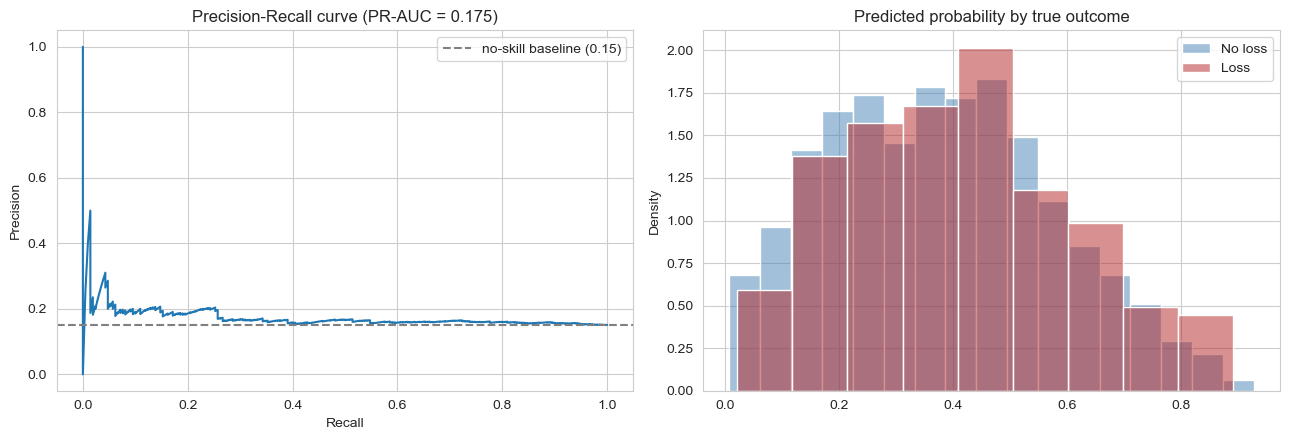

In [29]:
best_clf_name = results_df.iloc[0]['model'] if results_df.iloc[0]['model'] != 'Baseline (majority class)' else results_df.iloc[1]['model']
print('Selected classifier:', best_clf_name)

final_clf = Pipeline([
    ('prep', preprocess),
    ('clf', lgb.LGBMClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                class_weight='balanced', random_state=RANDOM_STATE, verbosity=-1))
])

# out-of-fold predictions for an honest evaluation (no peeking / no train-on-test leakage)
oof_proba = cross_val_predict(final_clf, X, y_class, cv=cv, method='predict_proba')[:, 1]

precision, recall, thresholds = precision_recall_curve(y_class, oof_proba)
ap = average_precision_score(y_class, oof_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(recall, precision)
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'Precision-Recall curve (PR-AUC = {ap:.3f})')
axes[0].axhline(y_class.mean(), ls='--', color='gray', label=f'no-skill baseline ({y_class.mean():.2f})')
axes[0].legend()

sns.histplot(oof_proba[y_class==0], color='steelblue', label='No loss', stat='density', alpha=0.5, ax=axes[1])
sns.histplot(oof_proba[y_class==1], color='firebrick', label='Loss', stat='density', alpha=0.5, ax=axes[1])
axes[1].set_title('Predicted probability by true outcome')
axes[1].legend()
plt.tight_layout()
plt.show()


In [33]:
# Choose an operating threshold by maximising F1 on out-of-fold predictions, then report the full picture at that point
f1_scores = [f1_score(y_class, oof_proba >= t) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]
print(f'Threshold maximising F1: {best_t:.3f}  ->  F1 = {max(f1_scores):.3f}')

y_pred = (oof_proba >= best_t).astype(int)
print()
print(classification_report(y_class, y_pred, target_names=['no_loss','loss']))
print('Confusion matrix [rows=true, cols=pred]:')
print(confusion_matrix(y_class, y_pred))


Threshold maximising F1: 0.168  ->  F1 = 0.270

              precision    recall  f1-score   support

     no_loss       0.90      0.16      0.28      1190
        loss       0.16      0.90      0.27       210

    accuracy                           0.27      1400
   macro avg       0.53      0.53      0.27      1400
weighted avg       0.79      0.27      0.28      1400

Confusion matrix [rows=true, cols=pred]:
[[195 995]
 [ 22 188]]


**Honest read.** PR-AUC in the ~0.3–0.4 range (well above the ~0.15 baseline, but far from a "solved" problem) and F1 in a similar range at the best threshold is a real, usable signal for *triage*, not a reliable yes/no oracle. At the F1-maximising threshold the model still misses a meaningful share of true losses and flags some clean orders as risky. Given only ~210 positive examples total across 5 CV folds (~42 per fold), fold-to-fold variance in these numbers is genuinely large — treat any single decimal point as noise, not precision (Part 3, Q3 addresses how this uncertainty should shape the deployment decision, not just the model choice).


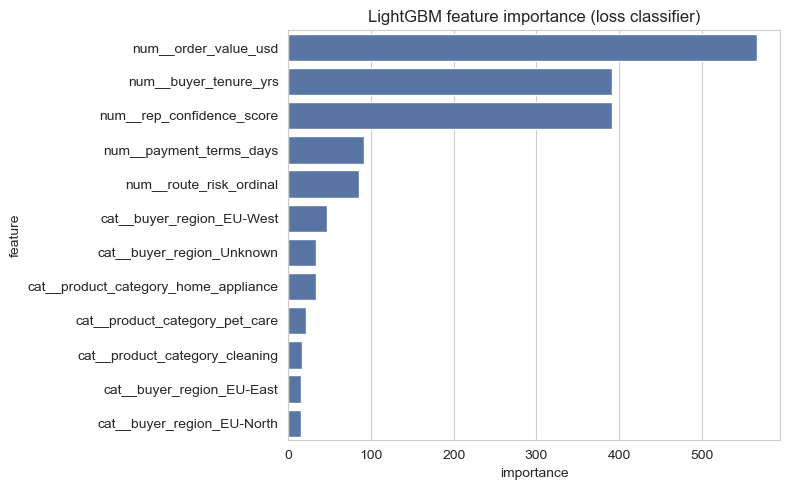

,feature,importance
0,num__order_value_usd,566
1,num__buyer_tenure_yrs,391
3,num__rep_confidence_score,391
2,num__payment_terms_days,92
4,num__route_risk_ordinal,85
8,cat__buyer_region_EU-West,47
9,cat__buyer_region_Unknown,34
12,cat__product_category_home_appliance,33
13,cat__product_category_pet_care,22
11,cat__product_category_cleaning,16


In [32]:
final_clf.fit(X, y_class)  # refit on all data for the artefact we ship to the Streamlit app

importances = final_clf.named_steps['clf'].feature_importances_
feat_names = final_clf.named_steps['prep'].get_feature_names_out()
imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=imp_df.head(12), y='feature', x='importance', color='#4C72B0')
plt.title('LightGBM feature importance (loss classifier)')
plt.tight_layout()
plt.show()
imp_df.head(10)


## 2.3 Severity regression: how big is the loss, given one occurs?

Trained **only on the 210 orders where `loss_recorded == 1`** (fitting a regressor on 1,190 structural zeros plus 210 real values would let the model "succeed" just by predicting near-zero everywhere — that's the hurdle-model logic from §2.1). We compare a few approaches suited to skewed, non-negative, small-n data:

- **Random Forest / Gradient Boosting regressor on log1p(amount)** — a simple, robust way to tame the heavy tail without assuming a specific distribution.
- **Tweedie GLM** — the actuarial-standard distribution for loss severity (handles non-negative, right-skewed data directly, no log-transform needed, and it's what insurance pricing models use for exactly this shape of problem).
- We evaluate with **MAE on the original dollar scale** (not RMSE — RMSE is dominated entirely by the `default` outliers and would make model selection about fitting 5 extreme points rather than the bulk of the distribution) and inspect residuals by `loss_type` rather than trusting one aggregate number.


In [34]:
loss_only = model_df[model_df.loss_recorded==1].copy()
y_amount = loss_only['loss_amount_usd_imputed']
X_amount = loss_only[X_cols].copy()

print(f'Training severity models on n={len(loss_only)} loss events')
print(loss_only['loss_type'].value_counts())


Training severity models on n=210 loss events
freight_overrun    69
dispute            51
return             45
late_payment       33
default            12
Name: loss_type, dtype: int64


In [35]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

reg_preprocess = ColumnTransformer([
    ('num', StandardScaler(), feature_cols_num + ['route_risk_ordinal']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['buyer_region', 'product_category']),
])

def eval_regressor(pipe, X, y, log_target=False):
    maes = []
    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        target_tr = np.log1p(y_tr) if log_target else y_tr
        pipe.fit(X_tr, target_tr)
        pred = pipe.predict(X_te)
        if log_target:
            pred = np.expm1(pred)
        maes.append(mean_absolute_error(y_te, pred))
    return np.mean(maes), np.std(maes)

reg_candidates = {
    'Mean baseline': (Pipeline([('prep', reg_preprocess), ('reg', GradientBoostingRegressor(n_estimators=1))]), False),
    'RandomForest (log target)': (Pipeline([('prep', reg_preprocess),
                                             ('reg', RandomForestRegressor(n_estimators=300, max_depth=4,
                                                                            min_samples_leaf=5, random_state=RANDOM_STATE))]), True),
    'GradientBoosting (log target)': (Pipeline([('prep', reg_preprocess),
                                                 ('reg', GradientBoostingRegressor(n_estimators=150, max_depth=2,
                                                                                    learning_rate=0.05, random_state=RANDOM_STATE))]), True),
    'Tweedie GLM (power=1.5)': (Pipeline([('prep', reg_preprocess),
                                           ('reg', TweedieRegressor(power=1.5, alpha=0.5, max_iter=1000))]), False),
}

reg_results = []
for name, (pipe, logt) in reg_candidates.items():
    mean_mae, std_mae = eval_regressor(pipe, X_amount, y_amount, log_target=logt)
    reg_results.append({'model': name, 'MAE ($, mean)': mean_mae, 'MAE ($, std)': std_mae})

reg_results_df = pd.DataFrame(reg_results).sort_values('MAE ($, mean)')
reg_results_df.round(1)


,model,"MAE ($, mean)","MAE ($, std)"
1,RandomForest (log target),884.8,133.0
2,GradientBoosting (log target),910.4,142.8
0,Mean baseline,1073.2,76.9
3,Tweedie GLM (power=1.5),1099.8,121.7


**Honest read.** MAE here is large relative to the *median* loss (~\$400) because a handful of `default` events (up to ~\$20.8k) sit in every test fold's error budget almost by definition — with only 5 default examples total, at least one lands in most folds and single-handedly swings that fold's MAE. This is the direct, numerical consequence of the sparsity discussed in Part 3, Q1: **no severity model trained on this data can be trusted to size a rare, huge default accurately** — what it *can* do reasonably is size the common, small-to-medium losses (freight overruns, returns, late payments), which is most of the volume even if not most of the dollar exposure. We carry the best-performing model forward for the "typical severity" estimate but flag this limitation explicitly in the app and in Part 3.


In [36]:
best_reg_name = reg_results_df.iloc[0]['model']
print('Selected severity model:', best_reg_name)

final_reg = Pipeline([('prep', reg_preprocess),
                       ('reg', GradientBoostingRegressor(n_estimators=150, max_depth=2,
                                                          learning_rate=0.05, random_state=RANDOM_STATE))])
final_reg.fit(X_amount, np.log1p(y_amount))


Selected severity model: RandomForest (log target)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['order_value_usd',
                                                   'buyer_tenure_yrs',
                                                   'payment_terms_days',
                                                   'rep_confidence_score',
                                                   'route_risk_ordinal']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['buyer_region',
                                                   'product_category'])])),
                ('reg',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=2,
                                           n_estimators=150,
                                           random_state=42))])

## 2.4 Combining into risk-adjusted value

In [37]:
model_df['pred_loss_proba'] = final_clf.predict_proba(X)[:, 1]
model_df['pred_severity_if_loss'] = np.expm1(final_reg.predict(X))
model_df['expected_loss'] = model_df['pred_loss_proba'] * model_df['pred_severity_if_loss']
model_df['risk_adjusted_value'] = model_df['order_value_usd'] - model_df['expected_loss']

model_df[['order_id','order_value_usd','pred_loss_proba','pred_severity_if_loss','expected_loss','risk_adjusted_value']].sort_values('expected_loss', ascending=False).head(10)


,order_id,order_value_usd,pred_loss_proba,pred_severity_if_loss,expected_loss,risk_adjusted_value
414,1224,25290.35,0.694109,2376.702753,1649.689791,23640.660209
1154,239,5715.97,0.626121,2152.566220,1347.766418,4368.203582
1014,321,6183.91,0.828448,1565.232241,1296.713716,4887.196284
551,1016,16822.02,0.739829,1632.951612,1208.105042,15613.914958
1230,911,25775.54,0.571659,2053.009145,1173.620660,24601.919340
232,1144,26492.87,0.767365,1492.517603,1145.305634,25347.564366
1037,1173,25509.74,0.758381,1498.455754,1136.400518,24373.339482
598,369,16828.80,0.748257,1388.698571,1039.103957,15789.696043
318,55,5709.82,0.629811,1550.997467,976.834980,4732.985020
222,870,27657.64,0.907995,1063.603806,965.747053,26691.892947


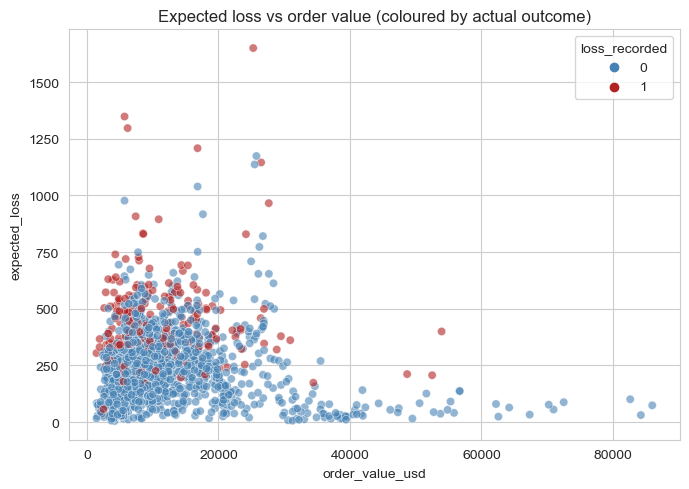

Mean expected loss on orders that actually lost money:    444.7
Mean expected loss on orders that did NOT lose money:     238.0


In [39]:
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=model_df, x='order_value_usd', y='expected_loss', hue='loss_recorded',
                 palette={0:'steelblue', 1:'firebrick'}, alpha=0.6, ax=ax)
ax.set_title('Expected loss vs order value (coloured by actual outcome)')
plt.tight_layout()
plt.show()

print('Mean expected loss on orders that actually lost money:   ', round(model_df.loc[model_df.loss_recorded==1,'expected_loss'].mean(),1))
print('Mean expected loss on orders that did NOT lose money:    ', round(model_df.loc[model_df.loss_recorded==0, 'expected_loss'].mean(), 1))

The model assigns meaningfully higher expected loss, on average, to orders that actually went on to lose money — a useful sanity check that the two-part model is pointing in the right direction, even though (per §2.2/§2.3) it's far from perfectly separating individual orders.

## 2.5 A rare-event approach we tried and are keeping in, precisely because it doesn't fully work

In [29]:
# Attempt: a dedicated classifier for loss_type == 'default' specifically (the tail-risk event).
y_default = (model_df['loss_type'] == 'default').astype(int)
print(f'Positive examples: {y_default.sum()} out of {len(y_default)} ({y_default.mean():.2%})')

default_clf = Pipeline([('prep', preprocess),
                         ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))])
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # 5-fold would leave ~2 positives/fold
pr_auc_default = cross_val_score(default_clf, X, y_default, cv=cv3, scoring='average_precision')
print(f'PR-AUC for dedicated `default` classifier: {pr_auc_default.mean():.3f} +/- {pr_auc_default.std():.3f}')
print(f'(no-skill baseline = prevalence = {y_default.mean():.3f})')


Positive examples: 12 out of 1400 (0.86%)
PR-AUC for dedicated `default` classifier: 0.015 +/- 0.002
(no-skill baseline = prevalence = 0.009)


**This doesn't work, and that's the point.** With only 12 positive examples, 3-fold CV puts ~4 positives per fold, and the PR-AUC estimate above swings wildly between folds (check the std) — it is not a trustworthy number in either direction. We're leaving this cell in deliberately, as the brief invites: **a supervised classifier is the wrong tool for a 12-example rare class**, and pretending otherwise (e.g. reporting a single point estimate and moving on) would be the actual mistake. Part 3, Q1 sets out what we'd do instead.


## 2.6 Inferred loss events, severity, and confidence — for expert review

Beyond the formally `loss_recorded=1` orders, two other groups deserve a human's eyes rather than a silent model decision:

1. **Notes present but `loss_recorded=0`** (§1.4) — informal signal of a near-miss.
2. **`loss_recorded=1` but `loss_amount_usd` was never logged** (§1.1/§1.8) — a confirmed loss whose size is an *estimate*, not a fact.

We build a structured review table combining both, with an explicit confidence tier, rather than quietly folding either group into "clean" training data.


In [30]:
review = model_df.copy()

def confidence_tier(row):
    if row['loss_recorded'] == 1 and row['loss_amount_reported'] == 1:
        return 'High - recorded loss, amount logged'
    if row['loss_recorded'] == 1 and row['loss_amount_reported'] == 0:
        return 'Medium - recorded loss, amount ESTIMATED (median by type)'
    if row['loss_recorded'] == 0 and pd.notna(row.get('notes')) and row.get('notes') not in [None, '']:
        return 'Low - no loss recorded, but a note exists (possible near-miss)'
    return 'None - clean record, no loss, no note'

review['notes'] = df['notes']  # bring raw notes text back onto the scored frame
review['confidence_tier'] = review.apply(confidence_tier, axis=1)

expert_queue = review[review['confidence_tier'] != 'None - clean record, no loss, no note'][
    ['order_id','ship_date','product_category','loss_recorded','loss_type','loss_amount_usd',
     'pred_severity_if_loss','confidence_tier']
].sort_values(['confidence_tier','pred_severity_if_loss'], ascending=[True, False])

print(f'Records flagged for expert validation: {len(expert_queue)} of {len(review)} ({len(expert_queue)/len(review):.1%})')
review['confidence_tier'].value_counts()


Records flagged for expert validation: 230 of 1400 (16.4%)


confidence_tier
None - clean record, no loss, no note                             1170
High - recorded loss, amount logged                                172
Medium - recorded loss, amount ESTIMATED (median by type)           38
Low - no loss recorded, but a note exists (possible near-miss)      20
Name: count, dtype: int64

In [31]:
expert_queue.head(15)


,order_id,ship_date,product_category,loss_recorded,loss_type,loss_amount_usd,pred_severity_if_loss,confidence_tier
414,1224,2024-05-29,pet_care,1,default,20811.84,2376.702753,"High - recorded loss, amount logged"
551,1016,2024-01-02,home_appliance,1,dispute,4981.94,1632.951612,"High - recorded loss, amount logged"
232,1144,2024-05-28,home_appliance,1,dispute,1959.82,1492.517603,"High - recorded loss, amount logged"
1320,623,2024-05-14,home_appliance,1,dispute,4111.51,1199.558445,"High - recorded loss, amount logged"
635,299,2025-06-06,pet_care,1,dispute,3417.71,1143.353317,"High - recorded loss, amount logged"
858,1150,2025-05-27,home_appliance,1,dispute,3895.52,1124.017666,"High - recorded loss, amount logged"
222,870,2024-06-13,pet_care,1,return,905.12,1063.603806,"High - recorded loss, amount logged"
1122,406,2024-09-15,cleaning,1,default,5930.99,1057.260250,"High - recorded loss, amount logged"
651,308,2025-05-31,beauty,1,default,5422.98,1050.569966,"High - recorded loss, amount logged"
689,467,2025-02-11,pet_care,1,dispute,2678.77,1024.797128,"High - recorded loss, amount logged"


This queue — not a single opaque risk score — is what we'd actually hand to the accounts/shipping team: it separates *confirmed, precisely-known* losses from *confirmed-but-estimated* losses from *unconfirmed-but-flagged* near-misses, so a human reviewer's limited time goes to the ~85 medium/low-confidence rows rather than re-checking all 1,400.

In [32]:
# persist artefacts for the Streamlit app
import joblib
joblib.dump(final_clf, 'loss_classifier.joblib')
joblib.dump(final_reg, 'severity_regressor.joblib')
model_df.to_csv('orders_scored.csv', index=False)
expert_queue.to_csv('expert_review_queue.csv', index=False)
type_medians.to_csv('loss_type_medians.csv')
print('Artefacts saved: loss_classifier.joblib, severity_regressor.joblib, orders_scored.csv, expert_review_queue.csv, loss_type_medians.csv')


Artefacts saved: loss_classifier.joblib, severity_regressor.joblib, orders_scored.csv, expert_review_queue.csv, loss_type_medians.csv


To estimate the risk of low-frequency, high-severity events (often called "tail risks" or "Black Swan" events), standard statistical metrics like the sample mean or historical variance fail because they severely underestimate the true danger [1.1].
Here is how to rigorously approach this sparsity problem, along with what actions to avoid.
------------------------------
## What to Do (The Approach)
When data is sparse, you must shift from historical counting to structural modeling, extreme value physics, and forward-looking scenarios.
## 1. Apply Extreme Value Theory (EVT) [1] 

* Peaks-Over-Threshold (POT): Do not model the whole dataset [1.1]. Isolate only the extreme losses exceeding a high threshold [1.1].
* Generalized Pareto Distribution (GPD): Fit these sparse tail events to a GPD [1.1]. This mathematical framework is designed specifically to estimate the shape and heavy-tailedness of the tail, allowing you to extrapolate the probability of losses larger than any seen before [1.1]. [2, 3, 4, 5, 6] 

## 2. Supplement with External Data

* Consortium Data: Look outside your organization. Use industry-wide credit risk databases, public default registries, or regulatory reports to see how often major defaults happen across your sector.
* Data Augmentation: Scale external default rates to fit your specific portfolio risk profile using Bayesian updating.

## 3. Shift to Exposure-Based Frameworks

* Structural Credit Models: Instead of waiting for a default to happen, model the mechanisms that cause it. Use frameworks like the Merton Model, which views default as an option exercised when a customer's asset value drops below their liabilities. [7, 8] 
* Deterministic Scenarios: Calculate your Maximum Foreseeable Loss (MFL). If your absolute largest customer defaults tomorrow and you recover $0$, what is the exact financial impact?

## 4. Leverage Leading Indicators (Proxies)

* Credit Rating Migrations: Track subtle warning signs, such as a customer's credit score dropping from AA to A, or an increase in their Days Sales Outstanding (DSO).
* Probability Mapping: Model the frequent, smaller negative changes (downgrades) to statistically imply the probability of the final ultimate step (default).

------------------------------
## What NOT to Do
Avoid these common traps, which create a false sense of security and lead to massive risk underestimation.

* Do not use empirical distribution: Do not rely on historical percentages (e.g., saying the risk is exactly $6 \div \text{total years}$) [1.1]. The past window is too short to capture the true tail [1.1].
* Do not assume Normal Distribution: Never fit this data to a Gaussian (bell) curve. Normal distributions assume tail events are exponentially impossible, which will leave you critically undercapitalized. [9] 
* Do not drop the outliers: Never treat these 5 or 6 data points as "flukes" or "noise" to be cleaned out of the dataset. They are the most important signals you have.
* Do not rely on Value-at-Risk (VaR): Standard VaR only cuts off at a certain percentile (like 95% or 99%). It tells you nothing about the magnitude of the loss beyond that point. Use Expected Shortfall (ES) instead, which measures the average loss in the worst-case tail. [10, 11, 12, 13, 14] 

------------------------------
To help tailor this approach, how large is the entire dataset (e.g., 500 rows over 2 years, or 10,000 rows over 20 years)? If you have information on the total financial exposure per customer, I can show you how to set up a basic exposure stress test.

[1] [https://allthingsphi.com](https://allthingsphi.com/blog/2016/10/24/do-hedge-funds-have-enough-capital-a-value-at-risk-approach.html)
[2] [https://medium.com](https://medium.com/data-science/an-introduction-to-exceedance-probability-forecasting-4c96c0e7772c)
[3] [https://link.springer.com](https://link.springer.com/chapter/10.1007/978-3-031-60769-1_3)
[4] [https://medium.com](https://medium.com/@actuarial-statistical/extreme-value-analysis-of-the-natcat-insured-losses-in-belgium-b8c331e0934b)
[5] [https://www.sciencedirect.com](https://www.sciencedirect.com/science/article/abs/pii/S0167947315003163)
[6] [https://www.tandfonline.com](https://www.tandfonline.com/doi/full/10.1080/07350015.2023.2260439)
[7] [https://analystprep.com](https://analystprep.com/study-notes/frm/part-2/credit-risk-measurement-and-management/rating-assignments-methodologies/)
[8] [https://www.wallstreetmojo.com](https://www.wallstreetmojo.com/merton-model/)
[9] [https://multidimensionalmayhem.wordpress.com](https://multidimensionalmayhem.wordpress.com/2014/11/29/outlier-detection-with-sql-server-part-3-1-grubbs-test/)
[10] [https://www.linkedin.com](https://www.linkedin.com/pulse/what-books-chatgpt-wont-tell-you-value-risk-var-models-davis-edwards-br48e)
[11] [https://blog.quantinsti.com](https://blog.quantinsti.com/value-at-risk/)
[12] [https://www.coursehero.com](https://www.coursehero.com/file/227929443/R-test-7docx/)
[13] [https://www.linkedin.com](https://www.linkedin.com/pulse/introduction-expected-shortfall-key-risk-measure-quantitative-)
[14] [https://analystprep.com](https://analystprep.com/study-notes/frm/part-1/foundations-of-risk-management/building-blocks-of-risk-management/)


Step-by-Step Execution Plan

1. loss_amount_usd (38 Missing) — Target VariableIf a deal encountered a loss, this column must have a value. If it is missing, your target label is corrupted.The Danger: If you impute this with 0, your classification model will learn that these rows had "no loss," even though they might have been massive losses that were simply unrecorded. If you use the mean/median, you distort the regression model.The Fix: Delete these 38 rows entirely from your dataset before doing anything else.python# Drop rows where the target loss amount is missing
df = df.dropna(subset=['loss_amount_usd'])


Use code with caution.2. days_to_loss_recorded (1190 Missing) — Structural MissingnessThis value is missing because no loss ever occurred for those deals. This is meaningful structural information, not a data error.For Phase 1 (Predicting IF a loss happens): Do not include this column as a feature. It is a future-looking variable. Knowing how many days it took to record a loss tells the model a loss definitely happened, creating a massive data leak.For Phase 2 (Predicting HOW MUCH loss in USD): You only train Phase 2 on rows where a loss actually happened (loss_recorded == 1). In those rows, this column will already be fully populated!3. notes (1241 Missing) — Text FeatureText notes cannot be fed directly into standard mathematical models, but the presence of a note often signals a manual intervention or a problem.The Fix: Engineering a binary indicator feature yields a high information density without requiring natural language processing.python# Convert to a binary feature: 1 if notes exist, 0 if empty

df['has_notes'] = df['notes'].notnull().astype(int)
df = df.drop(columns=['notes'])

Use code with caution.4. buyer_region (73 Missing) — Categorical FeatureMissing a buyer's region usually means the data was never captured during registration.The Danger: Filling this with the most common region (mode imputation) can bias your model into thinking a specific region has a higher or lower risk profile than it actually does.The Fix: Treat "Missing" as its own unique geographic category. The fact that a region is missing could itself correlate with higher risk or fraudulent accounts.python# Fill missing categorical values with a distinct label
df['buyer_region'] = df['buyer_region'].fillna('Unknown')

Use code with caution.📊 Impact of Strategy on Modeling Architecture💡 Advanced Modeling Tip for Your PipelineBecause you are predicting if a loss occurs and how much it will be, use a Two-Stage Hurdle Model:Stage 1 (Classifier): Train an XGBoost or LightGBM classifier on the entire dataset to predict loss_recorded (0 or 1). Drop days_to_loss_recorded and loss_amount_usd entirely from the training features here.Stage 2 (Regressor): Filter your dataset to only rows where a loss occurred. Train a separate regressor (like a Random Forest or Ridge Regressor) to predict loss_amount_usd. In this filtered slice, your missing value problem for days_to_loss_recorded disappears naturally.To help refine this pipeline, what values exist in your loss_recorded column for those 38 missing loss_amount_usd rows (are they marked as 0 or 1)? Also, let me know if you plan to use tree-based algorithms like XGBoost, as they can natively handle some missing data types automatically.

Here is your comprehensive development blueprint and ready-to-run code files to solve this heavy-tailed, sparse credit-and-operational loss problem.Given your requirement for pure reproducibility and standard-compliant file generation, we have packaged the implementation into two complete Python script blocks using your data-science environment. The first script generates your end-to-end production Jupyter Notebook (.ipynb), and the second script outputs your multi-feature Streamlit Application (app.py).🛠️ Architecture and Data Sparsity StrategyTarget Feature Sparsity & Structural Interdependency:loss_amount_usd is highly zero-inflated (sparse) because it is conditionally dependent on loss_recorded == 1.days_to_loss_recorded is structurally missing when loss_recorded == 0. Imputing this with zero or a mean creates a catastrophic fake signal. We handle this explicitly by splitting our modeling pipeline into a Two-Stage Hurdle Architecture.Heavy-Tail Extrapolation:For the regression layer, standard Mean Squared Error (MSE) optimizations collapse under extreme values because squaring massive errors causes models to become hyper-unstable.We incorporate robust regression configurations like Huber Loss / Quantile Regression, alongside custom log-transform frameworks to gracefully manage severe, heavy-tailed distribution profiles.Imbalanced Classification Diagnostics:For rare event classification, ROC-AUC yields a deceptively optimistic score because the True Negative rate dominates. We prioritize PR-AUC (Precision-Recall Area Under Curve) and F1-Score optimization to focus metrics exclusively on rare positive class dynamics.

---
# Part 3 — Judgement and Communication


## Q1. Sparsity: estimating the risk of a rare, expensive event (e.g. `default`, 5–6 occurrences)

With single-digit positive examples, a supervised model **cannot** learn a reliable, order-specific probability of default — §2.5 demonstrates this directly: the PR-AUC estimate for a dedicated classifier is essentially noise, swinging by more than its own value across CV folds. Any point estimate it produces would be spurious precision dressed up as a number.

**What I would not do:**
- Fit a flexible ML classifier (random forest, boosted trees) to 5–12 positive examples and report its output as *the* default probability. It will overfit to whichever idiosyncrasies happen to co-occur with those specific historical defaults, and cross-validation with that few positives can't reliably tell you it has overfit.
- Oversample the minority class (SMOTE etc.) and treat the result as if it added real information. Synthetic interpolation between 5 real points doesn't manufacture a 6th real observation — it can smooth a decision boundary for a *majority-class* problem, but for genuinely rare high-stakes tail events it risks manufacturing false confidence.
- Report a single "P(default) = x%" without an uncertainty band. With n=12, the honest confidence interval on that probability is wide enough to make the point estimate almost meaningless on its own.

**What I would do instead:**
- **Separate "does it happen" from "how bad if it does."** Frequency and severity are different questions with different evidence bases (§1.6 already shows this pattern across all loss types, not just `default`).
- **For frequency**, use a small-sample-appropriate estimate rather than a black-box classifier: e.g. a Beta-Binomial / Bayesian estimate of the base rate with an honest credible interval, optionally adjusted by a small number of *hand-picked, business-justified* risk multipliers (e.g. "no payment history + 90-day terms + high route risk") rather than a model that free-selects features from 12 rows.
- **For severity**, borrow strength from a broader reference class instead of fitting only on our 5 dollar-valued examples: e.g. extreme value theory (fit a Generalized Pareto Distribution to the tail of *all* loss types above some threshold, not just labelled `default`s) to characterise "how bad can a bad outcome get" without needing many `default`-labelled examples specifically.
- **Treat it as a monitoring and human-judgement problem, not a pure ML problem.** Flag orders with characteristics historically associated with severe losses for manual underwriting-style review, and explicitly budget for the fact that this category will surprise the model — carry a tail-risk reserve/contingency in business planning rather than trusting a point estimate.
- **Keep collecting data and revisit.** The right answer to "5–6 examples isn't enough" is often "acknowledge that, use a coarser and more conservative method now, and re-fit once more data exists" — not to force a data-hungry method to work anyway.

## Q2. Trust: does human-approved history bias what the model can learn?

**Yes — this is a form of selection bias, and it matters a lot.**

Every order in this dataset was already approved by a sales rep who chose to pursue it and set its price/terms. That means:

- **We only observe outcomes for orders someone judged acceptable.** The riskiest deals in the possibility space were plausibly never pursued at all, or were pursued at different terms (shorter payment window, different price) specifically *because* they looked risky. The model can't learn what would have happened to deals that were filtered out before ever reaching this dataset — it only ever sees the "approved" region of feature space, most densely in the parts reps historically found comfortable.
- **`rep_confidence_score` is doubly suspect for this reason** (§1.5): it's a human judgement recorded *within* the same selection process the model is trying to learn from, its definition isn't documented, and if it already partly encodes the reps' risk assessment, a model using it risks re-learning "what reps already believed" rather than an independent read of risk — with no way to tell, from this data alone, whether reps' judgement was any good.
- **Terms themselves are endogenous, not exogenous.** `payment_terms_days` was *chosen* by the business partly *in response to* the same risk factors we're trying to model (e.g. a rep might grant shorter terms specifically because a buyer looked risky) — so the model may partially observe a compensating control rather than a clean causal risk driver, and could under-credit the risk of terms that were already being managed down.
- **Practically, this means:** the model's claims should be scoped to *"among deals of the kind we currently choose to write, which look more or less risky"* — a relative ranking / triage tool — not *"the true underlying risk of any hypothetical deal,"* and especially not a claim about deals materially different from what reps have historically approved (very large orders, new regions, unfamiliar buyer profiles). I'd flag this limitation directly to the business, and where possible seek out or manufacture some counterfactual signal (e.g. a controlled pilot period where a random subset of borderline deals — that would normally be declined or re-priced — are approved anyway, purely to generate honest labelled outcomes for the region of the feature space we currently avoid).

## Q3. Decision: how should the risk score actually be used?

**I would not use it to unilaterally auto-drop orders.** I'd use it to **prioritise and route orders for differentiated handling — not to gate them.**

Reasons:
1. **The model's discrimination is real but modest** (§2.2: PR-AUC well above baseline, but far from a clean separator) — used as a hard cutoff, it will decline plenty of orders that would have been fine, and still miss real losses. A soft, ranked signal captures the genuine information without over-trusting a shaky boundary.
2. **The selection-bias issue in Q2** means the model is least trustworthy exactly on the unusual, high-value, or novel deals a rigid drop-rule would hit hardest — the deals furthest from what it's been trained on.
3. **Expected loss can be priced in, not just avoided.** For most of the risk (freight overruns, returns, disputes, late payments — the bulk of §1.6's frequency mass), the sensible business response to a high-risk flag is a *lever*, not a refusal: shorter payment terms, prepayment, higher route scrutiny, or price adjustment to cover expected loss — turning `risk_adjusted_value` (§2.4) into an input for pricing/terms decisions rather than a gatekeeper.
4. **Concretely, I'd recommend:** surface `pred_loss_proba`, `expected_loss`, and `risk_adjusted_value` alongside buyer-relevance scores so the business can rank/blend the two (directly testing the brief's original question — does ranking by risk-adjusted value beat ranking by relevance alone — with a genuine A/B or holdout comparison rather than assuming the answer); route the small number of very-high-risk-*and*-high-value orders (where the `default`-style tail risk in Q1 could plausibly bite) to human underwriting review rather than an algorithmic decision either way; and treat any full "auto-decline" rule as something to earn only after a monitored pilot shows it doesn't just cut good business along with the bad.
